# Support Vector Machines on `dataset_stratified.csv`

This notebook evaluates Support Vector Machines (SVMs) using the project split convention:

- `DATA_PATH` points to the sampled/stratified dataset used for training and validation;
- `DATA_PATH_TEST` points to the remaining/remainder dataset used only for final testing;
- the sampled/stratified dataset is split into 80% training and 20% validation with stratification;
- the remainder dataset is never used for model selection.

This notebook uses a justified validation strategy: hyperparameter selection is run on a stratified subset of the training set, then the selected model is evaluated once on a held-out stratified test set. You can raise the subset sizes if your machine can handle longer SVM runs.


> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


## 1. Setup

In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "05_svm_evaluation"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

from pathlib import Path
import os
import sys
import platform
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)

# Reproducibility and SVM runtime controls.
RANDOM_STATE = 42

# Target handling. The processed Covertype CSVs generated by notebook 01 use Cover_Type.
TARGET_COL = "Cover_Type"

# SVM computational controls.
# Keep MODEL_SELECTION_N modest because kernel SVM model selection can be expensive.
# Set to None to use the full 80% training split for hyperparameter search.
MODEL_SELECTION_N = 6000

# Final fit control. None means fit the selected model on the full 80% training split.
FINAL_TRAIN_N = None

# Learning-curve sample sizes drawn from the 80% training split.
LC_TRAIN_SIZES = [1000, 2500, 5000, 9000, 12000]

# Balanced class weighting reduces majority-class dominance on imbalanced Covertype classes.
CLASS_WEIGHT = "balanced"

# Larger cache can reduce repeated kernel computation overhead.
CACHE_SIZE_MB = 2000



PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-e

In [2]:
def hardware_note():
    # Return a compact hardware/software note for the runtime table.
    cpu = platform.processor() or platform.machine()
    py = platform.python_version()
    note = {
        "python_version": py,
        "platform": platform.platform(),
        "processor": cpu,
        "cpu_count_logical": os.cpu_count(),
    }
    try:
        import psutil
        note["memory_gb"] = round(psutil.virtual_memory().total / (1024**3), 2)
    except Exception:
        note["memory_gb"] = "psutil unavailable"
    return note

hardware = hardware_note()
hardware

{'python_version': '3.11.15',
 'platform': 'Linux-6.8.0-124-generic-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'cpu_count_logical': 12,
 'memory_gb': 15.29}

## 2. Load data and define features/target

`DATA_PATH` is used for the sampled/stratified train/validation source dataset. `DATA_PATH_TEST` is loaded separately and reserved for final testing only. The target column is detected as `Cover_Type`, `cover_type`, or `target` when present; otherwise the notebook uses the last column.


In [3]:
def require_csv(path: Path, variable_name: str):
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {variable_name} at {path.resolve()}. "
            f"Update {variable_name} to point to the correct CSV file."
        )

require_csv(DATA_PATH, "DATA_PATH")
require_csv(DATA_PATH_TEST, "DATA_PATH_TEST")

df_sample = pd.read_csv(DATA_PATH)
df_test = pd.read_csv(DATA_PATH_TEST)

print(f"Train/validation source loaded from DATA_PATH: {DATA_PATH}")
print(f"External test source loaded from DATA_PATH_TEST: {DATA_PATH_TEST}")
print(f"Sampled/stratified train-validation source shape: {df_sample.shape}")
print(f"External remainder test shape: {df_test.shape}")

df_sample.head()

Train/validation source loaded from DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
External test source loaded from DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Sampled/stratified train-validation source shape: (20000, 55)
External remainder test shape: (561012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2879,7,8,810,84,2230,211,225,151,949,...,0,0,0,0,0,0,0,0,0,2
1,2630,5,23,42,9,1511,184,190,137,2021,...,0,0,0,0,0,0,0,0,0,2
2,2856,46,13,228,40,3336,224,211,119,2940,...,0,0,0,0,0,0,0,0,0,2
3,2959,311,10,443,44,2900,194,233,179,1485,...,0,0,0,0,0,0,0,0,0,2
4,2309,162,4,127,46,1019,223,240,152,860,...,0,0,0,0,0,0,0,0,0,3


In [4]:
def detect_target_column(frame: pd.DataFrame, preferred: str | None = None) -> str:
    if preferred is not None:
        if preferred not in frame.columns:
            raise ValueError(f"TARGET_COL='{preferred}' was not found. Available columns: {frame.columns.tolist()}")
        return preferred

    for candidate in ["Cover_Type", "cover_type", "target", "class", "label"]:
        if candidate in frame.columns:
            return candidate
    return frame.columns[-1]

TARGET_COL = detect_target_column(df_sample, TARGET_COL)
if TARGET_COL not in df_test.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' from DATA_PATH is missing in DATA_PATH_TEST. "
        f"DATA_PATH_TEST columns: {df_test.columns.tolist()}"
    )

feature_cols = [col for col in df_sample.columns if col != TARGET_COL]
missing_test_features = sorted(set(feature_cols) - set(df_test.columns))
extra_test_features = sorted(set(df_test.columns) - set(feature_cols) - {TARGET_COL})

if missing_test_features:
    raise ValueError(f"DATA_PATH_TEST is missing feature columns: {missing_test_features}")
if extra_test_features:
    print(f"Warning: DATA_PATH_TEST contains extra columns that will be ignored: {extra_test_features}")

X = df_sample[feature_cols].copy()
y = df_sample[TARGET_COL].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test[TARGET_COL].copy()

print(f"Target column: {TARGET_COL}")
print(f"Train/validation source rows: {len(df_sample):,}")
print(f"External test rows: {len(df_test):,}")
print(f"Features: {X.shape[1]:,}")
print(f"Train/validation classes: {y.nunique()} -> {sorted(y.unique())}")
print(f"External test classes: {y_test.nunique()} -> {sorted(y_test.unique())}")
print(f"Sample missing values: {int(df_sample.isna().sum().sum()):,}")
print(f"Test missing values: {int(df_test.isna().sum().sum()):,}")
print(f"Sample duplicate rows: {int(df_sample.duplicated().sum()):,}")
print(f"Test duplicate rows: {int(df_test.duplicated().sum()):,}")

class_summary = (
    y.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="sample_count")
)
class_summary["sample_percent"] = 100 * class_summary["sample_count"] / len(y)

test_class_summary = (
    y_test.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="test_count")
)
test_class_summary["test_percent"] = 100 * test_class_summary["test_count"] / len(y_test)

class_summary = class_summary.merge(test_class_summary, on="class", how="outer").fillna(0)
class_summary.to_csv(RESULTS_METRICS_DIR / "01_svm_class_distribution_trainval_and_test.csv", index=False)
class_summary


Target column: Cover_Type
Train/validation source rows: 20,000
External test rows: 561,012
Features: 54
Train/validation classes: 7 -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
External test classes: 7 -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Sample missing values: 0


Test missing values: 0
Sample duplicate rows: 0


Test duplicate rows: 0


,class,sample_count,sample_percent,test_count,test_percent
0,1,7292,36.460,204548,36.460539
1,2,9752,48.760,273549,48.759920
2,3,1231,6.155,34523,6.153701
3,4,94,0.470,2653,0.472895
4,5,327,1.635,9166,1.633833
5,6,598,2.990,16769,2.989063
6,7,706,3.530,19804,3.530049


## 3. SVM preprocessing strategy

SVMs are sensitive to feature scale because both the linear margin and RBF kernel depend on dot products or distances in feature space. Covertype has continuous terrain variables with different units and magnitudes, plus binary wilderness/soil indicators. The preprocessing below standardizes continuous non-binary features and passes binary indicators through as 0/1 values. This scales the numeric terrain variables while avoiding over-amplifying rare binary soil indicators.


In [5]:
def detect_binary_columns(frame: pd.DataFrame):
    binary_cols = []
    for col in frame.columns:
        values = frame[col].dropna().unique()
        if len(values) <= 2 and set(values).issubset({0, 1, 0.0, 1.0, False, True}):
            binary_cols.append(col)
    return binary_cols

binary_cols = detect_binary_columns(X)
numeric_cols = [c for c in X.columns if c not in binary_cols]

print(f"Continuous/non-binary columns scaled: {len(numeric_cols)}")
print(f"Binary indicator columns passed through: {len(binary_cols)}")

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ],
    remainder="drop",
)

Continuous/non-binary columns scaled: 10
Binary indicator columns passed through: 44


## 4. Train/validation/test strategy

The sampled/stratified dataset from `DATA_PATH` is split into an 80% training split and a 20% validation split using stratification. The external remainder dataset from `DATA_PATH_TEST` is held out for final testing and is not used for hyperparameter selection, learning curves, or model-complexity curves.

Because kernel SVMs can be computationally expensive, hyperparameter selection may train on a stratified subset of the 80% training split while evaluating on the fixed 20% validation split. This keeps the validation target consistent through the notebook and avoids leaking the external test set into model selection.


In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "external_test"],
    "source": ["DATA_PATH", "DATA_PATH", "DATA_PATH_TEST"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "percent_of_sampled_stratified_dataset": [
        len(X_train) / len(X),
        len(X_valid) / len(X),
        np.nan,
    ],
})

split_summary.to_csv(RESULTS_METRICS_DIR / "02_svm_split_summary.csv", index=False)
print(f"Training split from DATA_PATH: {X_train.shape}")
print(f"Validation split from DATA_PATH: {X_valid.shape}")
print(f"External test set from DATA_PATH_TEST: {X_test.shape}")
split_summary


Training split from DATA_PATH: (16000, 54)
Validation split from DATA_PATH: (4000, 54)
External test set from DATA_PATH_TEST: (561012, 54)


,split,source,rows,percent_of_sampled_stratified_dataset
0,train,DATA_PATH,16000,0.8
1,validation,DATA_PATH,4000,0.2
2,external_test,DATA_PATH_TEST,561012,NaN


In [7]:
def stratified_subsample(X_in, y_in, n=None, random_state=RANDOM_STATE):
    # Return a stratified subset of size n. If n is None or >= len(X_in), return all rows.
    if n is None or n >= len(X_in):
        return X_in.copy(), y_in.copy()
    X_sub, _, y_sub, _ = train_test_split(
        X_in,
        y_in,
        train_size=n,
        stratify=y_in,
        random_state=random_state,
    )
    return X_sub.copy(), y_sub.copy()

X_ms_train, y_ms_train = stratified_subsample(X_train, y_train, MODEL_SELECTION_N)
X_ms_val, y_ms_val = X_valid.copy(), y_valid.copy()

print(f"Model-selection training subset from 80% training split: {X_ms_train.shape}")
print(f"Model-selection validation set from fixed 20% validation split: {X_ms_val.shape}")

Model-selection training subset from 80% training split: (6000, 54)
Model-selection validation set from fixed 20% validation split: (4000, 54)


## 5. Hyperparameter sweep: linear and RBF SVMs

The sweep uses broad values that can reveal underfitting, saturation, or overfitting:

- linear SVM: `C = [0.01, 0.1, 1, 10]`;
- RBF SVM: `C = [0.1, 1, 10]` and `gamma = ['scale', 0.01, 0.1]`.

`C` controls regularization strength. Smaller `C` permits a wider-margin, more regularized classifier; larger `C` penalizes violations more heavily and can fit more complex boundaries. For RBF, `gamma` controls locality. Larger `gamma` makes the kernel more local and can increase variance; smaller `gamma` smooths the decision boundary.


In [8]:
def build_svm(kernel, C, gamma=None):
    params = {
        "kernel": kernel,
        "C": C,
        "class_weight": CLASS_WEIGHT,
        "cache_size": CACHE_SIZE_MB,
    }
    if kernel == "rbf":
        params["gamma"] = gamma
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("svm", SVC(**params)),
        ]
    )


def evaluate_pipeline(model, X_train, y_train, X_val, y_val):
    # Fit model and return metrics plus wall-clock fit/predict times.
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = model.predict(X_val)
    predict_time = time.perf_counter() - t1

    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "fit_time_sec": fit_time,
        "predict_time_sec": predict_time,
    }

search_space = []
for C in [0.01, 0.1, 1, 10]:
    search_space.append({"kernel": "linear", "C": C, "gamma": None})
for C in [0.1, 1, 10]:
    for gamma in ["scale", 0.01, 0.1]:
        search_space.append({"kernel": "rbf", "C": C, "gamma": gamma})

results = []
for i, cfg in enumerate(search_space, start=1):
    print(f"[{i}/{len(search_space)}] Fitting {cfg}")
    model = build_svm(**cfg)
    metrics = evaluate_pipeline(model, X_ms_train, y_ms_train, X_ms_val, y_ms_val)
    results.append({**cfg, **metrics})

results_df = pd.DataFrame(results)
results_df["gamma_label"] = results_df["gamma"].astype(str)
results_df = results_df.sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df


[1/13] Fitting {'kernel': 'linear', 'C': 0.01, 'gamma': None}


[2/13] Fitting {'kernel': 'linear', 'C': 0.1, 'gamma': None}


[3/13] Fitting {'kernel': 'linear', 'C': 1, 'gamma': None}


[4/13] Fitting {'kernel': 'linear', 'C': 10, 'gamma': None}


[5/13] Fitting {'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale'}


...

[10/13] Fitting {'kernel': 'rbf', 'C': 1, 'gamma': 0.1}


[11/13] Fitting {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}


[12/13] Fitting {'kernel': 'rbf', 'C': 10, 'gamma': 0.01}


[13/13] Fitting {'kernel': 'rbf', 'C': 10, 'gamma': 0.1}


,kernel,C,gamma,accuracy,macro_f1,balanced_accuracy,fit_time_sec,predict_time_sec,gamma_label
0,rbf,10.00,0.1,0.75700,0.623861,0.668976,1.465868,1.160913,0.1
1,rbf,10.00,scale,0.74350,0.622872,0.682900,1.650613,1.233351,scale
2,rbf,1.00,0.1,0.68900,0.580084,0.695534,1.938757,1.445250,0.1
3,rbf,1.00,scale,0.68325,0.577476,0.700665,1.921659,1.508000,scale
4,rbf,10.00,0.01,0.66050,0.563488,0.731031,1.719802,1.365012,0.01
5,linear,1.00,None,0.62600,0.524858,0.700073,1.563681,0.753804,NaN
6,linear,10.00,None,0.62275,0.517661,0.684356,2.881405,0.717722,NaN
7,rbf,0.10,0.1,0.60275,0.511469,0.708237,3.080212,1.682463,0.1
8,rbf,0.10,scale,0.59975,0.507146,0.707869,3.030905,1.667948,scale
9,rbf,1.00,0.01,0.61075,0.505002,0.711118,2.267217,1.574228,0.01


In [9]:
# saving the hyperparameter/runtime table for the report.
results_df.to_csv(RESULTS_RUNTIME_DIR / "03_svm_hyperparameter_runtime_results.csv", index=False)

best_cfg = results_df.iloc[0].to_dict()
best_cfg


{'kernel': 'rbf',
 'C': 10.0,
 'gamma': 0.1,
 'accuracy': 0.757,
 'macro_f1': 0.6238607102097429,
 'balanced_accuracy': 0.668975707896783,
 'fit_time_sec': 1.4658678690029774,
 'predict_time_sec': 1.160913134983275,
 'gamma_label': '0.1'}

## 6. Model-complexity curves

The first curve shows validation macro-F1 versus `C` for each kernel. The second curve focuses on the RBF kernel and shows validation macro-F1 versus `gamma` at the best observed RBF `C`. Macro-F1 is used for model selection because it weights classes equally and is more informative than accuracy for imbalanced multiclass Covertype classification.


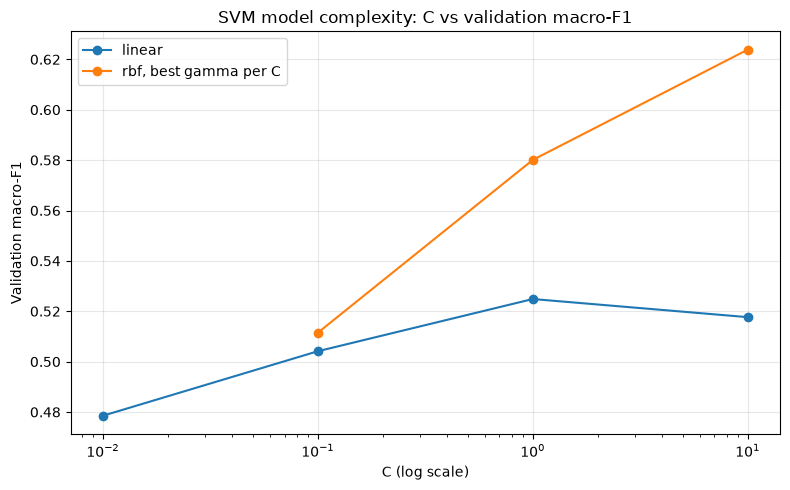

In [10]:
# Model-complexity curve 1: C versus validation macro-F1 by kernel.
plt.figure(figsize=(8, 5))
for kernel in sorted(results_df["kernel"].unique()):
    if kernel == "linear":
        subset = results_df[results_df["kernel"] == kernel].sort_values("C")
        plt.plot(subset["C"], subset["macro_f1"], marker="o", label="linear")
    else:
        # For RBF, plot the best gamma observed at each C.
        subset = (
            results_df[results_df["kernel"] == "rbf"]
            .sort_values("macro_f1", ascending=False)
            .groupby("C", as_index=False)
            .first()
            .sort_values("C")
        )
        plt.plot(subset["C"], subset["macro_f1"], marker="o", label="rbf, best gamma per C")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Validation macro-F1")
plt.title("SVM model complexity: C vs validation macro-F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "01_svm_model_complexity_C_macro_f1.png", dpi=200)
plt.show()

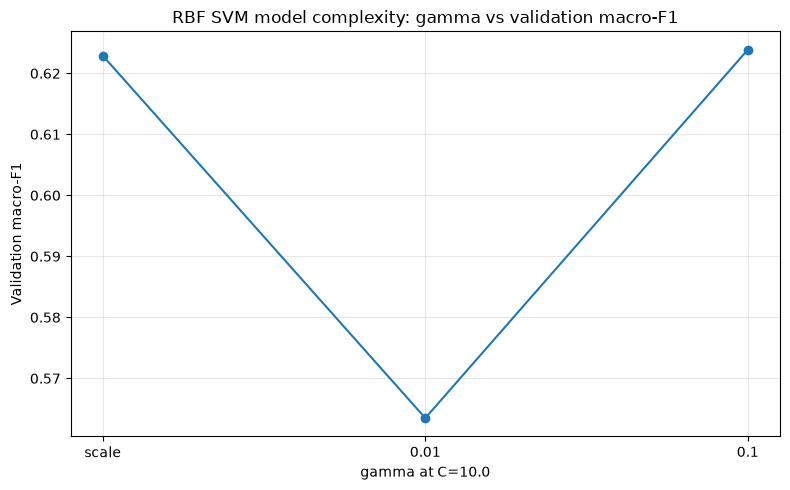

,kernel,C,gamma,accuracy,macro_f1,balanced_accuracy,fit_time_sec,predict_time_sec,gamma_label,gamma_sort
1,rbf,10.0,scale,0.7435,0.622872,0.682900,1.650613,1.233351,scale,-1.00
4,rbf,10.0,0.01,0.6605,0.563488,0.731031,1.719802,1.365012,0.01,0.01
0,rbf,10.0,0.1,0.7570,0.623861,0.668976,1.465868,1.160913,0.1,0.10


In [11]:
# Model-complexity curve 2: RBF gamma versus validation macro-F1 at best RBF C.
rbf_df = results_df[results_df["kernel"] == "rbf"].copy()
if not rbf_df.empty:
    best_rbf_C = rbf_df.sort_values(["macro_f1", "balanced_accuracy"], ascending=False).iloc[0]["C"]
    gamma_curve = rbf_df[rbf_df["C"] == best_rbf_C].copy()

    def gamma_sort_key(g):
        if str(g) == "scale":
            return -1.0
        return float(g)

    gamma_curve["gamma_sort"] = gamma_curve["gamma"].map(gamma_sort_key)
    gamma_curve = gamma_curve.sort_values("gamma_sort")

    plt.figure(figsize=(8, 5))
    plt.plot(gamma_curve["gamma_label"], gamma_curve["macro_f1"], marker="o")
    plt.xlabel(f"gamma at C={best_rbf_C}")
    plt.ylabel("Validation macro-F1")
    plt.title("RBF SVM model complexity: gamma vs validation macro-F1")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "02_svm_model_complexity_gamma_macro_f1.png", dpi=200)
    plt.show()

gamma_curve if 'gamma_curve' in globals() else None


## 7. Learning curves for the selected operating point

The selected model is refit on increasing stratified training sizes and evaluated on a fixed validation set. A large train/validation gap suggests high variance; both curves low and close suggests underfitting/high bias; a validation curve still rising suggests that more data may help.


In [12]:
# Learning curves use the project split directly:
# - training pool: X_train/y_train, the 80% split from DATA_PATH
# - validation set: X_valid/y_valid, the fixed 20% split from DATA_PATH
X_lc_pool, y_lc_pool = X_train.copy(), y_train.copy()
X_lc_val, y_lc_val = X_valid.copy(), y_valid.copy()

max_lc_n = len(X_lc_pool)
train_sizes = [n for n in LC_TRAIN_SIZES if n < max_lc_n]
if len(train_sizes) < 4:
    # Fallback to four stratified sizes if the configured values exceed the available data.
    train_sizes = np.linspace(max(100, len(np.unique(y_lc_pool)) * 10), max_lc_n, 4, dtype=int).tolist()
train_sizes = sorted(set(train_sizes))
print(train_sizes)

[1000, 2500, 5000, 9000, 12000]


In [13]:
def cfg_from_row(row):
    kernel = row["kernel"]
    C = float(row["C"])
    gamma = row["gamma"] if kernel == "rbf" else None
    # Convert gamma back from possible NaN/string forms.
    if kernel == "rbf" and isinstance(gamma, str):
        gamma = gamma if gamma == "scale" else float(gamma)
    return {"kernel": kernel, "C": C, "gamma": gamma}

selected_cfg = cfg_from_row(best_cfg)
print(selected_cfg)

lc_rows = []
for n in train_sizes:
    X_lc_train, y_lc_train = stratified_subsample(X_lc_pool, y_lc_pool, n, random_state=RANDOM_STATE + n)
    model = build_svm(**selected_cfg)

    t0 = time.perf_counter()
    model.fit(X_lc_train, y_lc_train)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_train_pred = model.predict(X_lc_train)
    train_predict_time = time.perf_counter() - t1

    t2 = time.perf_counter()
    y_val_pred = model.predict(X_lc_val)
    val_predict_time = time.perf_counter() - t2

    lc_rows.append({
        "train_size": n,
        "train_macro_f1": f1_score(y_lc_train, y_train_pred, average="macro"),
        "validation_macro_f1": f1_score(y_lc_val, y_val_pred, average="macro"),
        "train_balanced_accuracy": balanced_accuracy_score(y_lc_train, y_train_pred),
        "validation_balanced_accuracy": balanced_accuracy_score(y_lc_val, y_val_pred),
        "fit_time_sec": fit_time,
        "train_predict_time_sec": train_predict_time,
        "validation_predict_time_sec": val_predict_time,
    })

lc_df = pd.DataFrame(lc_rows)
lc_df.to_csv(RESULTS_MODEL_COMPARISON_DIR / "04_svm_learning_curve_results.csv", index=False)
lc_df

{'kernel': 'rbf', 'C': 10.0, 'gamma': 0.1}


,train_size,train_macro_f1,validation_macro_f1,train_balanced_accuracy,validation_balanced_accuracy,fit_time_sec,train_predict_time_sec,validation_predict_time_sec
0,1000,0.935699,0.479982,0.962680,0.467451,0.060491,0.062831,0.241931
1,2500,0.863486,0.572301,0.945785,0.605877,0.298618,0.322388,0.520899
2,5000,0.853858,0.579949,0.939032,0.627270,1.068445,1.245640,1.201916
3,9000,0.828212,0.623150,0.930715,0.684652,3.302349,3.884409,1.701406
4,12000,0.815619,0.635464,0.926304,0.713032,5.800002,7.017817,2.603185


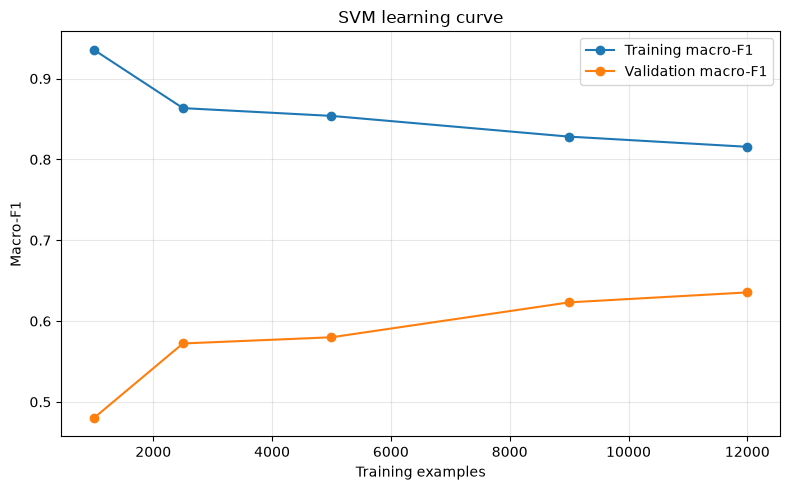

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(lc_df["train_size"], lc_df["train_macro_f1"], marker="o", label="Training macro-F1")
plt.plot(lc_df["train_size"], lc_df["validation_macro_f1"], marker="o", label="Validation macro-F1")
plt.xlabel("Training examples")
plt.ylabel("Macro-F1")
plt.title("SVM learning curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "03_svm_learning_curve_macro_f1.png", dpi=200)
plt.show()

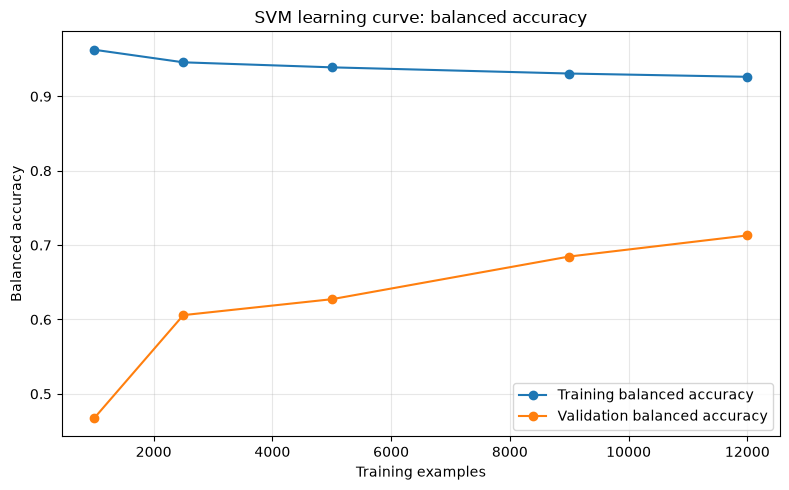

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(lc_df["train_size"], lc_df["train_balanced_accuracy"], marker="o", label="Training balanced accuracy")
plt.plot(lc_df["train_size"], lc_df["validation_balanced_accuracy"], marker="o", label="Validation balanced accuracy")
plt.xlabel("Training examples")
plt.ylabel("Balanced accuracy")
plt.title("SVM learning curve: balanced accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "04_svm_learning_curve_balanced_accuracy.png", dpi=200)
plt.show()

## 8. Final held-out test evaluation
The selected SVM is refit on the 80% training split from `DATA_PATH`, then evaluated once on the external remainder test set from `DATA_PATH_TEST`. The 20% validation split is not used for this final fit, keeping the train/validation/test roles consistent and explicit.


In [16]:
X_final_train, y_final_train = stratified_subsample(X_train, y_train, FINAL_TRAIN_N)
print(f"Final SVM training rows: {len(X_final_train):,} / {len(X_train):,} from the 80% training split")
print(f"Final external test rows: {len(X_test):,} from DATA_PATH_TEST")

final_model = build_svm(**selected_cfg)

t0 = time.perf_counter()
final_model.fit(X_final_train, y_final_train)
final_fit_time = time.perf_counter() - t0

t1 = time.perf_counter()
y_test_pred = final_model.predict(X_test)
final_predict_time = time.perf_counter() - t1

final_metrics = {
    "kernel": selected_cfg["kernel"],
    "C": selected_cfg["C"],
    "gamma": selected_cfg["gamma"],
    "final_train_rows": len(X_final_train),
    "validation_rows": len(X_valid),
    "test_rows": len(X_test),
    "test_source": str(DATA_PATH_TEST),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "fit_time_sec": final_fit_time,
    "predict_time_sec": final_predict_time,
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(RESULTS_RUNTIME_DIR / "05_svm_final_test_metrics_runtime.csv", index=False)
final_metrics_df


Final SVM training rows: 16,000 / 16,000 from the 80% training split
Final external test rows: 561,012 from DATA_PATH_TEST


,kernel,C,gamma,final_train_rows,validation_rows,test_rows,test_source,accuracy,macro_f1,balanced_accuracy,fit_time_sec,predict_time_sec
0,rbf,10.0,0.1,16000,4000,561012,/home/vision/Repos/ml-model-evaluation-and-opt...,0.762166,0.675519,0.762279,10.334737,438.175198


<Figure size 800x700 with 0 Axes>

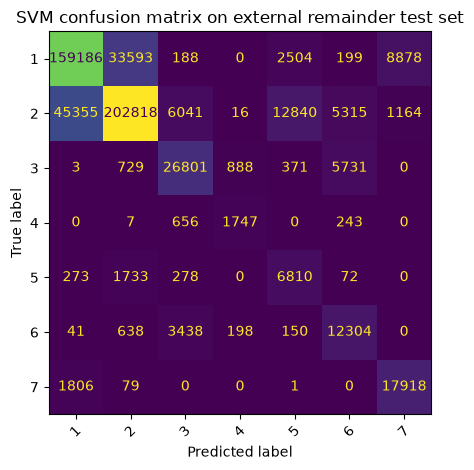

In [17]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", xticks_rotation=45, colorbar=False)
plt.title("SVM confusion matrix on external remainder test set")
plt.tight_layout()
plt.savefig(FIG_CONFUSION_MATRICES_DIR / "05_svm_confusion_matrix.png", dpi=200)
plt.show()

In [18]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    labels=labels,
    zero_division=0,
)

per_class_df = pd.DataFrame({
    "class": labels,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
})
per_class_df.to_csv(RESULTS_METRICS_DIR / "06_svm_per_class_test_metrics.csv", index=False)
per_class_df


,class,precision,recall,f1,support
0,1,0.770265,0.778233,0.774228,204548
1,2,0.846496,0.741432,0.790488,273549
2,3,0.716566,0.776323,0.745249,34523
3,4,0.613198,0.658500,0.635042,2653
4,5,0.300318,0.742963,0.427737,9166
5,6,0.515588,0.733735,0.605616,16769
6,7,0.640844,0.904767,0.750272,19804


In [19]:
print(classification_report(y_test, y_test_pred, labels=labels, zero_division=0))


              precision    recall  f1-score   support

           1       0.77      0.78      0.77    204548
           2       0.85      0.74      0.79    273549
           3       0.72      0.78      0.75     34523
           4       0.61      0.66      0.64      2653
           5       0.30      0.74      0.43      9166
           6       0.52      0.73      0.61     16769
           7       0.64      0.90      0.75     19804

    accuracy                           0.76    561012
   macro avg       0.63      0.76      0.68    561012
weighted avg       0.78      0.76      0.77    561012



## 9. Runtime table and hardware note
The table below includes fit and predict wall-clock times for the final selected model on the external test set from `DATA_PATH_TEST`. The hyperparameter-search and learning-curve CSVs saved in `results/svm/` provide additional runtime evidence.


In [20]:
runtime_table = pd.DataFrame([
    {
        "stage": "final selected SVM",
        "kernel": selected_cfg["kernel"],
        "C": selected_cfg["C"],
        "gamma": selected_cfg["gamma"],
        "train_rows": len(X_final_train),
        "validation_rows": len(X_valid),
        "test_rows": len(X_test),
        "test_source": str(DATA_PATH_TEST),
        "fit_time_sec": final_fit_time,
        "predict_time_sec": final_predict_time,
    }
])
runtime_table.to_csv(RESULTS_RUNTIME_DIR / "svm_runtime_table.csv", index=False)

print("Hardware note:")
for k, v in hardware.items():
    print(f"- {k}: {v}")

runtime_table

Hardware note:
- python_version: 3.11.15
- platform: Linux-6.8.0-124-generic-x86_64-with-glibc2.39
- processor: x86_64
- cpu_count_logical: 12
- memory_gb: 15.29


,stage,kernel,C,gamma,train_rows,validation_rows,test_rows,test_source,fit_time_sec,predict_time_sec
0,final selected SVM,rbf,10.0,0.1,16000,4000,561012,/home/vision/Repos/ml-model-evaluation-and-opt...,10.334737,438.175198
